In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
df = pd.read_csv("Final_data.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [4]:
print(df.columns.tolist())

['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method', 'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle', 'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin']


## 1. Which diet type had the people with lowest BMI?

Average BMI by Diet Type:
    diet_type   BMI_calc
5  Vegetarian  24.701889
3       Paleo  24.710915
0    Balanced  24.875832
1        Keto  24.953481
2    Low-Carb  25.140329
4       Vegan  25.148536


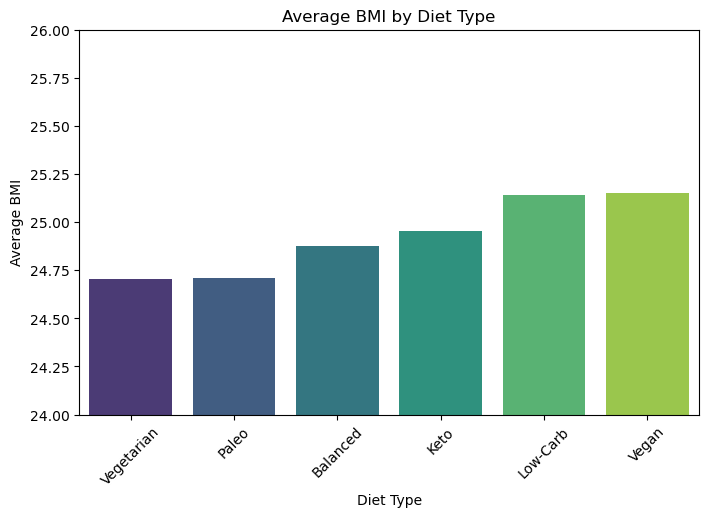

In [11]:
df.columns = df.columns.str.strip().str.replace("(", "").str.replace(")", "")

bmi_col = 'BMI_calc'

avg_bmi_by_diet = df.groupby('diet_type')[bmi_col].mean().reset_index().sort_values(by=bmi_col)

print("Average BMI by Diet Type:")
print(avg_bmi_by_diet)

plt.figure(figsize=(8,5))

sns.barplot(data=avg_bmi_by_diet, x='diet_type', y=bmi_col, palette='viridis', hue='diet_type')
plt.title("Average BMI by Diet Type")
plt.ylim(bottom=24, top=26)
plt.xlabel("Diet Type")
plt.ylabel("Average BMI")
plt.xticks(rotation=45)
plt.show()

## 2. Does higher water intake relate to lower fat percentage?

['Fat_Percentage', 'Water_Intake_liters', 'Fats']


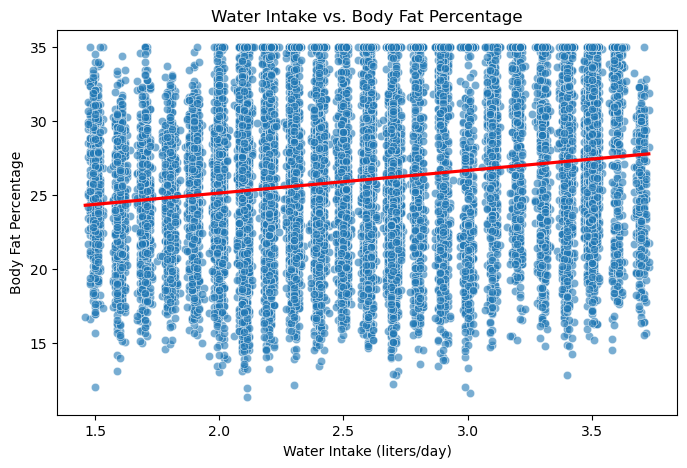

In [51]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

print([col for col in df.columns if "Water" in col or 'Fat' in col])

water_col = 'Water_Intake_liters'
fat_col = 'Fat_Percentage'

plt.figure(figsize=(8,5))
sns.scatterplot(x=water_col, y=fat_col, data=df, alpha=0.6)
sns.regplot(x=water_col, y=fat_col, data=df, scatter=False, color='red')
plt.title("Water Intake vs. Body Fat Percentage")
plt.xlabel("Water Intake (liters/day)")
plt.ylabel("Body Fat Percentage")
plt.show()

['Fat_Percentage', 'Water_Intake_liters', 'Fats']


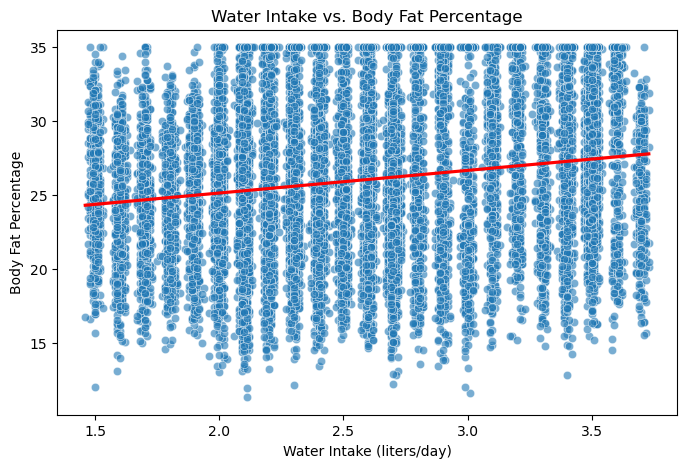

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt 

df.comlumns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

print([col for col in df.columns if "Water" in col or 'Fat' in col])

water_col = 'Water_Intake_liters'
fat_col = 'Fat_Percentage'

plt.figure(figsize=(8,5))
sns.scatterplot(x=water_col, y=fat_col, data=df, alpha=0.6)
sns.regplot(x=water_col, y=fat_col, data=df, scatter=False, color='red')
plt.title("Water Intake vs. Body Fat Percentage")
plt.xlabel("Water Intake (liters/day)")
plt.ylabel("Body Fat Percentage")
plt.show()

## 3. What is the average BMI for males and females?

In [22]:
# Data Cleaning
sub = df[["Gender", "BMI", "Proteins"]].copy()

# normalize gender labels (e.g., "male" -> "Male")
sub["Gender"] = sub["Gender"].astype(str).str.strip().str.title()

# make sure BMI and Proteins are numeric
sub["BMI"] = pd.to_numeric(sub["BMI"], errors="coerce")
sub["Proteins"] = pd.to_numeric(sub["Proteins"], errors="coerce")

In [23]:
# Show the first few rows of the cleaned dataset
sub.head()

,Gender,BMI,Proteins
0,Male,24.87,106.05
1,Female,23.48,85.41
2,Female,21.15,98.11
3,Female,32.45,80.84
4,Male,14.83,133.05


Gender
Female    24.850667
Male      24.993092
Name: BMI, dtype: float64


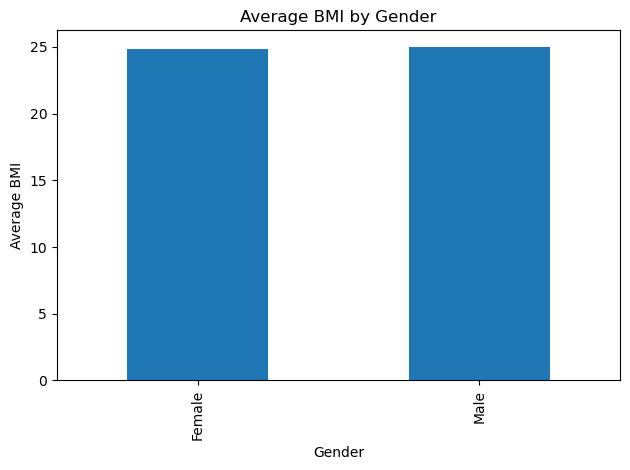

In [8]:
avg_bmi_by_gender = (
    sub.dropna(subset=["BMI", "Gender"])
       .groupby("Gender")["BMI"]
       .mean()
       .sort_values()
)
print(avg_bmi_by_gender)

# Simple bar chart (matplotlib, one plot, no color settings)
plt.figure()
avg_bmi_by_gender.plot(kind="bar")
plt.ylabel("Average BMI")
plt.title("Average BMI by Gender")
plt.tight_layout()
plt.show()

## 4. How much protein did the top five people with the lowest BMI consume vs the top five people that had the highest BMI?

In [9]:
# Average of each for the five lowest and the five highests BMI

# Make sure BMI and Proteins are numeric
sub = df[["Gender", "BMI", "Proteins"]].copy()
sub["BMI"] = pd.to_numeric(sub["BMI"], errors="coerce")
sub["Proteins"] = pd.to_numeric(sub["Proteins"], errors="coerce")

# Drop missing values
sub = sub.dropna(subset=["BMI", "Proteins"])

# Get top 5 lowest BMI
lowest5 = sub.sort_values("BMI", ascending=True).head(5)

# Get top 5 highest BMI
highest5 = sub.sort_values("BMI", ascending=False).head(5)

# Display both tables
print("Top 5 people with the LOWEST BMI:")
display(lowest5)

print("Top 5 people with the HIGHEST BMI:")
display(highest5)

# Calculate total and average protein for each group
total_protein_lowest5 = lowest5["Proteins"].sum()
avg_protein_lowest5 = lowest5["Proteins"].mean()

total_protein_highest5 = highest5["Proteins"].sum()
avg_protein_highest5 = highest5["Proteins"].mean()

# Print the results including the total and average protein
print("---- Protein Summary ----")
print(f"Lowest 5 BMI - Total Protein: {total_protein_lowest5:.2f}, Average Protein: {avg_protein_lowest5:.2f}")
print(f"Highest 5 BMI - Total Protein: {total_protein_highest5:.2f}, Average Protein: {avg_protein_highest5:.2f}")

Top 5 people with the LOWEST BMI:


,Gender,BMI,Proteins
1299,Female,12.04,114.01
15874,Male,12.08,115.11
4736,Male,12.12,114.19
17639,Male,12.14,113.82
403,Female,12.15,114.45


Top 5 people with the HIGHEST BMI:


,Gender,BMI,Proteins
8906,Female,50.23,107.65
1411,Female,50.17,108.21
10778,Male,50.08,107.77
17888,Female,50.05,108.28
16164,Male,49.97,108.31


---- Protein Summary ----
Lowest 5 BMI - Total Protein: 571.58, Average Protein: 114.32
Highest 5 BMI - Total Protein: 540.22, Average Protein: 108.04


In [10]:
# Based on these results people with the lowest BMI consumed more protein on average by around 5.5%

## 5. Does the Frequency of Exercise Vary Across Different Age Groups?

Age_Group
18-24    3.270214
25-34    3.331295
35-44    3.366582
45-54    3.312155
55-64    3.294536
65+           NaN
Name: Workout_Frequency (days/week), dtype: float64


/var/folders/gf/jr9zyvdn6c12f4q2ll9mr6940000gn/T/ipykernel_13442/2889673751.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_avg = Health.groupby("Age_Group")["Workout_Frequency (days/week)"].mean()
/var/folders/gf/jr9zyvdn6c12f4q2ll9mr6940000gn/T/ipykernel_13442/2889673751.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


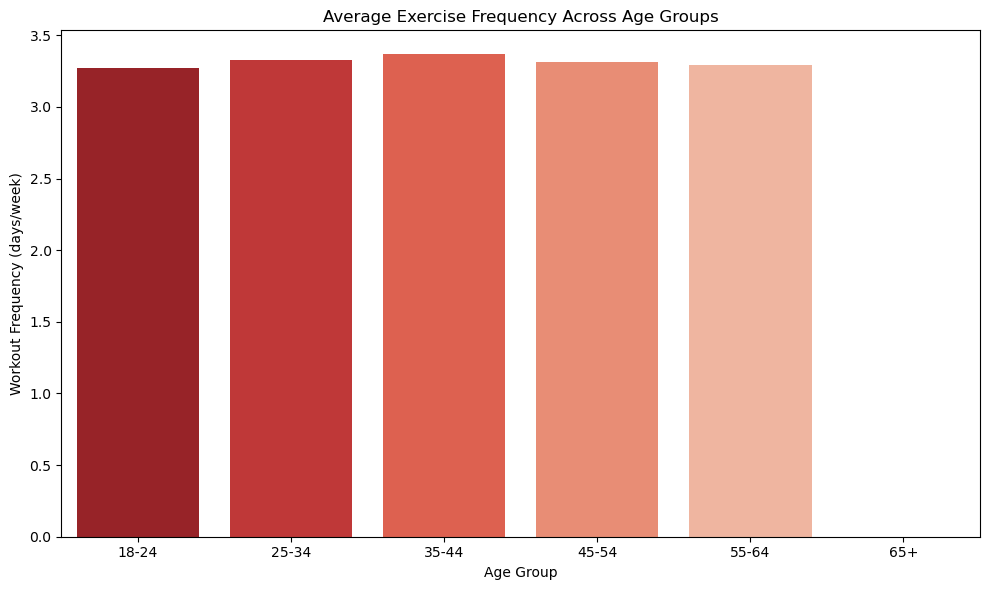

In [34]:
Health = df[['Age', 'Workout_Frequency (days/week)']].dropna()
Health['Age_Group'] = pd.cut(
    df['Age'], 
    bins=[18,25,35,45,55,65,100],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'] )

group_avg = Health.groupby("Age_Group")["Workout_Frequency (days/week)"].mean()
print(group_avg)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=group_avg.index,
    y=group_avg.values,
    palette="Reds_r"
)
plt.title("Average Exercise Frequency Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Workout Frequency (days/week)")
plt.tight_layout()
plt.show()

## 6. Can protein intake per kg, age, and gender predict BMI?

In [43]:
df.columns = df.columns.str.strip()
model = df[['protein_per_kg', 'BMI', 'Age','Gender']].dropna()
model['Gender'] = model['Gender'].map({'Male':1, 'Female':0})
X = model[['protein_per_kg', 'Age','Gender']]
Y = model['BMI']
X = sm.add_constant(X)
regression_model = sm.OLS(Y,X).fit()
print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     4507.
Date:                Wed, 17 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:53:23   Log-Likelihood:                -61259.
No. Observations:               20000   AIC:                         1.225e+05
Df Residuals:                   19996   BIC:                         1.226e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             36.3154      0.160    227.

## 7. Which age group had the highest lean mass?

In [18]:
bins = [0, 30, 40, 50, 100]
labels = ["<30", "30-40", "40-50", "50+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)
lean_mass_by_group = df.groupby("Age_Group", observed=False)["lean_mass_kg"].mean()
print("Average Lean Mass by Age Group:")
print(lean_mass_by_group)
print("\nAge group with highest lean mass:", lean_mass_by_group.idxmax())

Average Lean Mass by Age Group:
Age_Group
<30      55.358944
30-40    53.645099
40-50    52.283003
50+      53.654565
Name: lean_mass_kg, dtype: float64

Age group with highest lean mass: <30


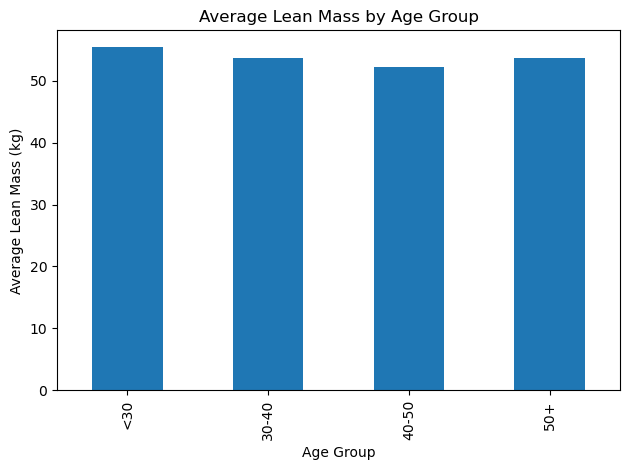

In [22]:
lean_mass_by_group.plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Average Lean Mass (kg)")
plt.title("Average Lean Mass by Age Group")
plt.tight_layout()
plt.show()

## 8. Which workout types lead to the highest calories burned out?

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_data.csv") 
cal_by_type = (
    df.groupby("Workout_Type")["Calories_Burned"]
      .mean()
      .sort_values(ascending=False)
)
print("Average calories burned by workout type:")
print(cal_by_type)

Average calories burned by workout type:
Workout_Type
HIIT        1652.533209
Strength    1361.430459
Cardio      1211.544680
Yoga         897.107216
Name: Calories_Burned, dtype: float64


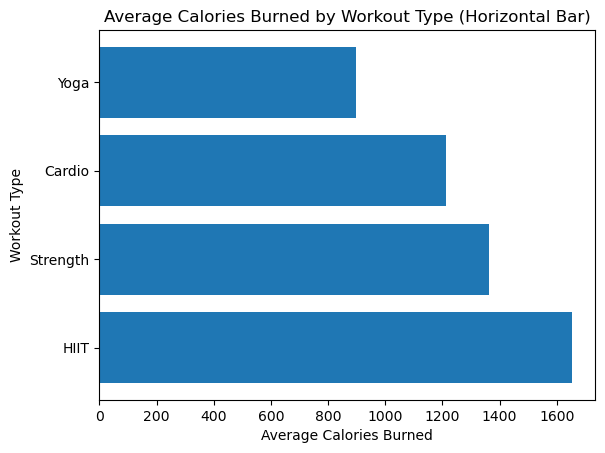

In [29]:
plt.barh(cal_by_type.index, cal_by_type.values)
plt.xlabel("Average Calories Burned")
plt.ylabel("Workout Type")
plt.title("Average Calories Burned by Workout Type (Horizontal Bar)")
plt.show()